# Spoofing a data distribution in Clustered Federated Learning

**The setting.** Clients differ in *what data they hold*. One hospital sees mostly one
condition, another sees a different mix. This is **statistical heterogeneity**, and it is
the reason Clustered Federated Learning exists: the server groups clients with similar data
so each group trains a model suited to it.

**The attack.** I hold data from group A. I want to be inside group B, because from inside I
receive B's model and my updates are averaged into B's. To get there I have to look like a
member of B, which means **imitating B's data distribution**.

**The question this notebook answers.** How does that imitation actually work, how much does
the attacker need to know about the target to do it, and what does it cost?

> This is an attack analysis. I do not build or propose a defence here. Where I measure how
> visible something is, that describes the attack's signature.

## Orientation: three ways to imitate a distribution

The attacker has three routes, and they differ in what they change and what bounds them.

| route | what it changes | bounded by |
|---|---|---|
| **declare** | the label histogram it reports, nothing else | nothing, it is an unverified field |
| **resample** | its own training data, drawn to match the target | **what it actually holds** |
| **prior-edit** | the final layer's bias, after training | **nothing** |

`resample` is the honest one: the model genuinely learns the distribution it is about to
claim. But an attacker holding no examples of a class cannot manufacture them, so the
imitation falls short by exactly that missing mass.

`prior-edit` has no such limit. Shifting the output layer's bias by the log-ratio of the two
distributions is **logit adjustment** (Menon et al., ICLR 2021), a published technique from
long-tail learning, applied here for a purpose it was not intended for. It can make a model
claim a class it has never seen.

**The three numbers to watch as you read:** how well the imitation matched (`achieved`
against `target`), whether the server was fooled (`infiltration`, always beside its
control), and what it cost in accuracy.

## Configuration

In [1]:
# One dict drives every experiment. QUICK reduces SEEDS only and must never
# touch the knowledge levels or the control, because a "quick" mode that
# silently drops the control is how a previous study lost its central claim.
CONFIG = dict(
    DATASET       = "mnist",
    NUM_CLIENTS   = 12,
    N_GROUPS      = 2,
    ARCH          = "mlp_flat",
    ROUNDS        = 6,
    EPOCHS        = 2,
    MAX_TRAIN     = 12000,
    ATTACKER      = 0,
    CONCENTRATION = 20.0,   # how tightly clients hug their group's label profile
    OVERLAP       = 0.3,    # mass each group shares with all classes
    KNOWLEDGE     = ("oracle", "inferred", "blind"),
    SEEDS         = (0, 1, 2, 3, 4),
    QUICK         = False,
)
if CONFIG["QUICK"]:
    CONFIG["SEEDS"] = CONFIG["SEEDS"][:1]

assert "blind" in CONFIG["KNOWLEDGE"], "blind is the baseline the others must beat"

for k, v in CONFIG.items():
    print(f"{k:<14} {v}")

DATASET        mnist
NUM_CLIENTS    12
N_GROUPS       2
ARCH           mlp_flat
ROUNDS         6
EPOCHS         2
MAX_TRAIN      12000
ATTACKER       0
CONCENTRATION  20.0
OVERLAP        0.3
KNOWLEDGE      ('oracle', 'inferred', 'blind')
SEEDS          (0, 1, 2, 3, 4)
QUICK          False


In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd

from seeding import set_global_seeds, describe_device
set_global_seeds(0, backend="torch")

from lab_data import load_bundle_torch, partition_label_hists
from clustering import SattlerCosineClusterer
from fl_loop import TorchFederatedServer
from attacks import ClusterSteering, TargetEstimator
from data import label_histogram
from aggregation import stack
from lab_probe import mean_output_prior_torch
from metrics import js_divergence, separation_ratio
from run_context import (boot_ci, use_report_style, show,
                         per_seed_breakdown, save_run)
from sklearn.metrics import adjusted_rand_score
import analysis

use_report_style()
print(describe_device())


def bundle(seed, overlap=None, partition="clustered"):
    # partition="clustered" plants GENUINE distribution groups: each group gets a
    # label profile and its members are drawn around it. Plain Dirichlet cannot
    # be used here, for the reason measured in Part 1.
    return load_bundle_torch(
        CONFIG["DATASET"], num_clients=CONFIG["NUM_CLIENTS"], partition=partition,
        n_groups=CONFIG["N_GROUPS"], seed=seed, max_train=CONFIG["MAX_TRAIN"],
        concentration=CONFIG["CONCENTRATION"],
        overlap=CONFIG["OVERLAP"] if overlap is None else overlap)


def group_profile(b, g):
    '''The mean label histogram of a planted group: what its data looks like.'''
    H = partition_label_hists(b)
    return H[np.asarray(b.groups) == g].mean(axis=0)


def sides(b):
    '''(attacker's home group, its target group, the target's member list).'''
    home = int(b.groups[CONFIG["ATTACKER"]])
    target_g = 1 - home
    members = [i for i in range(CONFIG["NUM_CLIENTS"]) if b.groups[i] == target_g]
    return home, target_g, members


def infiltration_of(history, attacker, target_members):
    '''Rounds where the attacker shared a cluster with most of the target group.

    Counted only where more than one cluster exists: before a split there is
    nothing to infiltrate, and scoring those rounds either way is wrong.
    Membership is tracked by WHO, never by cluster name, because names are
    reassigned every round.
    '''
    out = []
    for e in history:
        if len(e["membership"]) < 2:
            continue
        where = {c: cid for cid, ms in e["membership"].items() for c in ms}
        votes = {}
        for m in target_members:
            votes[where.get(m)] = votes.get(where.get(m), 0) + 1
        out.append(where.get(attacker) == max(votes, key=votes.get))
    return out

cuda: NVIDIA GeForce RTX 4060 Laptop GPU (8.6 GB), torch 2.5.1+cu121


## Part 1. What statistical heterogeneity has to look like for any of this to mean something

There are two ways to make clients statistically heterogeneous, and only one of them
produces *groups*.

**Dirichlet partitioning** is the standard non-Independent-and-Identically-Distributed
generator in the federated learning literature. It gives every client its own random skew.
Each client differs from every other, but there is no structure connecting some clients to
others.

**Planted profiles** give each *group* a label distribution and draw its members around it.
Now clients within a group resemble each other and differ from the other group.

The distinction decides whether this study is possible at all. If there are no groups, then
"the attacker infiltrated group B" is a statement about an arbitrary set of clients.

In [3]:
# Score every possible 2-way split of the 12 clients by the ratio of cross-group
# to within-group Jensen-Shannon divergence: how much more different the two
# halves are from each other than their own members are from each other. The
# maximum over all splits is the best grouping that EXISTS in the data, which is
# a ceiling no clusterer can beat.
rows = []
for label, kw in (("Dirichlet(0.05)", dict(partition="dirichlet", alpha=0.05)),
                  ("Dirichlet(0.2)",  dict(partition="dirichlet", alpha=0.2)),
                  ("Dirichlet(1.0)",  dict(partition="dirichlet", alpha=1.0))):
    b_d = load_bundle_torch(CONFIG["DATASET"], num_clients=CONFIG["NUM_CLIENTS"],
                            seed=0, max_train=CONFIG["MAX_TRAIN"], **kw)
    H = partition_label_hists(b_d); n = len(H)
    ratios = []
    for mask in range(1, 2 ** (n - 1)):
        left = [i for i in range(n) if (mask >> i) & 1]
        right = [i for i in range(n) if not (mask >> i) & 1]
        if min(len(left), len(right)) < 2:
            continue
        ratios.append(separation_ratio([H[left], H[right]])["ratio"])
    rows.append({"partition": label, "best_split_available": max(ratios),
                 "median_split": float(np.median(ratios))})

# The planted alternative, scored the same way on its true grouping.
for ov in (0.0, 0.3, 0.5):
    b_p = bundle(CONFIG["SEEDS"][0], overlap=ov)
    H = partition_label_hists(b_p)
    rows.append({"partition": f"planted, overlap={ov}",
                 "best_split_available": separation_ratio(
                     [H[np.asarray(b_p.groups) == g] for g in range(CONFIG["N_GROUPS"])]
                 )["ratio"],
                 "median_split": np.nan})

# Every value gets its null beside it. For a separation ratio the analytic null
# is 1.0, groups no more different from each other than from their own members.
table = pd.DataFrame(rows)
table["baseline (no structure)"] = analysis.BASELINES["separation_ratio"]["null"]
table["x above baseline"] = (table["best_split_available"]
                             / analysis.BASELINES["separation_ratio"]["null"]).round(2)
rows = table.to_dict("records")

show(pd.DataFrame(rows).round(2), "Is there any group structure to find?")
print()
print("baseline: a separation ratio of 1.0 means the two halves are no more")
print("different from each other than their own members are. The measured median")
print("over every random split is the honest null and sits at ~0.99.")
print("\nThe best grouping that exists ANYWHERE in Dirichlet data scores barely above a")
print("median random split. Dirichlet produces individually skewed clients, not groups.")
print("Planted profiles produce structure an order of magnitude stronger, which is what")
print("makes 'the attacker joined group B' a meaningful statement.")


Is there any group structure to find?
           partition  best_split_available  median_split  baseline (no structure)  x above baseline
     Dirichlet(0.05)                  1.65          0.99                      1.0              1.65
      Dirichlet(0.2)                  1.43          0.99                      1.0              1.43
      Dirichlet(1.0)                  1.46          0.99                      1.0              1.46
planted, overlap=0.0                 17.31           NaN                      1.0             17.31
planted, overlap=0.3                  4.51           NaN                      1.0              4.51
planted, overlap=0.5                  2.38           NaN                      1.0              2.38

baseline: a separation ratio of 1.0 means the two halves are no more
different from each other than their own members are. The measured median
over every random split is the honest null and sits at ~0.99.

The best grouping that exists ANYWHERE in Dirichlet da

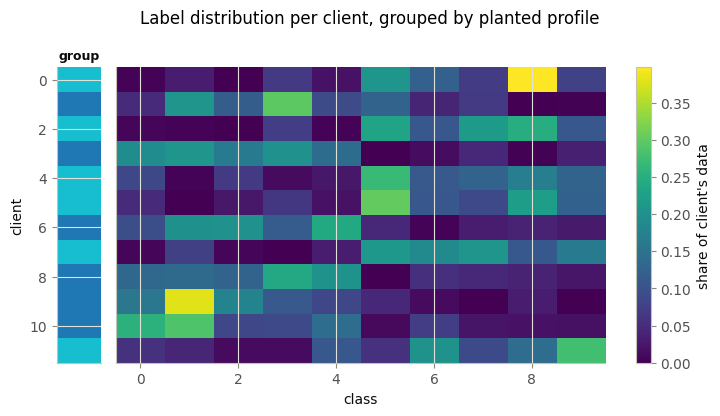

[analysis] saved plot -> docs\figures\dist_labelhist.png

The two planted label profiles
         class 0  class 1  class 2  class 3  class 4  class 5  class 6  class 7  class 8  class 9
group 0    0.147    0.237    0.146    0.176    0.150    0.038    0.033    0.035    0.021    0.018
group 1    0.035    0.026    0.018    0.038    0.035    0.213    0.141    0.133    0.215    0.146

attacker is client 0, born into group 1, targeting group 0
its own data     : [0.004 0.032 0.    0.067 0.02  0.207 0.123 0.071 0.398 0.079]
the target's data: [0.147 0.237 0.146 0.176 0.15  0.038 0.033 0.035 0.021 0.018]


In [4]:
# What the planted heterogeneity actually looks like, as data rather than as a
# number. Rows are clients, columns are classes, the strip marks the planted
# group. Block structure here is the thing the server is trying to recover.
b = bundle(CONFIG["SEEDS"][0])
H = partition_label_hists(b)
home, target_g, target_members = sides(b)

analysis.plot_label_histograms(
    H, "docs/figures/dist_labelhist.png", groups=b.groups,
    title="Label distribution per client, grouped by planted profile")

profiles = pd.DataFrame(
    {f"group {g}": np.round(group_profile(b, g), 3) for g in range(CONFIG["N_GROUPS"])},
    index=[f"class {c}" for c in range(b.num_classes)]).T
show(profiles, "The two planted label profiles")
print(f"\nattacker is client {CONFIG['ATTACKER']}, born into group {home}, "
      f"targeting group {target_g}")
print(f"its own data     : {np.round(label_histogram(np.asarray(b.client_data[CONFIG['ATTACKER']][1]), b.num_classes), 3)}")
print(f"the target's data: {np.round(group_profile(b, target_g), 3)}")

## Part 2. Can a server actually cluster on this, and how?

Two mechanisms, and they use completely different information.

**Declared**: the client reports its label histogram and the server groups similar ones.
Cheap, and entirely unverified.

**Inferred**: the server ignores what clients say and clusters on the *updates* they submit,
using cosine similarity of the deltas. This is Sattler's method and it is what most of the
Clustered Federated Learning literature actually does.

Both are scored by Adjusted Rand Index against the planted grouping: 1.0 is exact recovery,
0.0 is no better than a random partition of the same shape.

In [5]:
# DECLARED channel: cluster the reported histograms, no training involved.
declared_rows = []
for s in CONFIG["SEEDS"]:
    b_s = bundle(s)
    H_s = partition_label_hists(b_s)
    labels, _ = analysis.cluster_by_label_hist(H_s, n_clusters=CONFIG["N_GROUPS"])
    declared_rows.append({"seed": s, "ari": adjusted_rand_score(b_s.groups, labels)})

declared = pd.DataFrame(declared_rows)
declared["baseline (random partition)"] = analysis.BASELINES["ari"]["null"]
show(declared.round(3), "Declared channel: clustering on the reported label histogram")
print()
print("baseline: ARI is chance-corrected, so a random partition of the same shape")
print("scores 0.0, as does putting every client in one cluster. 1.0 is exact recovery.")
print()
print("Cross-reference: cfl-spoofing.ipynb reports 0.665 for this same channel. That")
print("is not a contradiction. The declared label histogram IS the distribution, so")
print("under distribution shift it is a faithful signal and recovers the grouping")
print("exactly. Under concept shift the groups share a label marginal by design and")
print("the channel only leaks through class imbalance, which is the weaker 0.665.")
print(f"\nARI {declared['ari'].mean():.3f}. The declared channel works, which is exactly")
print("why it is worth attacking: the server relies on a field the client writes and")
print("cannot check.")


Declared channel: clustering on the reported label histogram
 seed  ari  baseline (random partition)
    0  1.0                          0.0
    1  1.0                          0.0
    2  1.0                          0.0
    3  1.0                          0.0
    4  1.0                          0.0

baseline: ARI is chance-corrected, so a random partition of the same shape
scores 0.0, as does putting every client in one cluster. 1.0 is exact recovery.

Cross-reference: cfl-spoofing.ipynb reports 0.665 for this same channel. That
is not a contradiction. The declared label histogram IS the distribution, so
under distribution shift it is a faithful signal and recovers the grouping
exactly. Under concept shift the groups share a label marginal by design and
the channel only leaks through class imbalance, which is the weaker 0.665.

ARI 1.000. The declared channel works, which is exactly
why it is worth attacking: the server relies on a field the client writes and
cannot check.


In [6]:
# INFERRED channel: does the same structure show up in the submitted updates?
# Held open (eps1=-1 never splits) so the geometry is measured before any split
# changes what deltas are referenced against.
set_global_seeds(CONFIG["SEEDS"][0], backend="torch")
probe = SattlerCosineClusterer(eps1=-1.0, scope="head")
server = TorchFederatedServer(b.input_shape, b.num_classes, probe,
                              arch=CONFIG["ARCH"], n_clusters=CONFIG["N_GROUPS"],
                              seed=CONFIG["SEEDS"][0])
for r in range(4):
    _, updates, _ = server.run_round(b.client_data, round_num=r, epochs=CONFIG["EPOCHS"])
deltas = stack([u.metadata["delta_vec"] for u in updates])

signal = pd.DataFrame([
    {"scope": "full vector", **{k: analysis.clustering_signal(deltas, b.groups)[k]
                                for k in ("auc", "within", "cross", "margin")}},
    {"scope": "classifier head", **{k: analysis.clustering_signal(
        deltas, b.groups, index=probe.head_index)[k]
        for k in ("auc", "within", "cross", "margin")}},
])
signal["baseline (chance)"] = analysis.BASELINES["auc"]["null"]
signal["verdict"] = [analysis.compare_to_baseline("auc", a)["verdict"]
                     for a in signal["auc"]]
show(signal.round(4), "Inferred channel: does the update carry the group structure?")
print()
print("baseline: AUC 0.5 is chance, meaning the similarity ordering says nothing")
print("about who belongs together. 1.0 means every within-group pair is closer than")
print("every cross-group pair.")
print("\nAUC of 1.0 means every within-group pair is more similar than every cross-group")
print("pair, so the server can separate them. The margin says by how much.")


Inferred channel: does the update carry the group structure?
          scope    auc  within   cross  margin  baseline (chance)        verdict
    full vector 0.8852  0.9992  0.9990  0.0002                0.5 above baseline
classifier head 1.0000  0.5620 -0.1925  0.7545                0.5 above baseline

baseline: AUC 0.5 is chance, meaning the similarity ordering says nothing
about who belongs together. 1.0 means every within-group pair is closer than
every cross-group pair.

AUC of 1.0 means every within-group pair is more similar than every cross-group
pair, so the server can separate them. The margin says by how much.


## Part 3. How the imitation works, and what bounds it

This is the mechanism, and it is the part worth understanding in detail.

The attacker wants to look like the target group. Two honest-ish ways to do it and one
dishonest one, from the orientation table above.

In [7]:
# RESAMPLE. Draw a new training set from the attacker's OWN data, weighted so
# the label mix approaches the target's. The model then genuinely learns the
# distribution it is claiming. The bound is that you can only draw what you have.
attacker_y = np.asarray(b.client_data[CONFIG["ATTACKER"]][1])
own = label_histogram(attacker_y, b.num_classes)
target_profile = group_profile(b, target_g)

attack = ClusterSteering(malicious_clients=[CONFIG["ATTACKER"]], mechanism="data",
                         beta=1.0, num_classes=b.num_classes, seed=CONFIG["SEEDS"][0])
attack.target_hist = target_profile
Xr, yr = attack.training_data(CONFIG["ATTACKER"], *b.client_data[CONFIG["ATTACKER"]])
achieved = label_histogram(np.asarray(yr), b.num_classes)

comparison = pd.DataFrame({
    "attacker's own data": np.round(own, 3),
    "the target's profile": np.round(target_profile, 3),
    "achieved by resampling": np.round(achieved, 3),
    "shortfall": np.round(np.maximum(target_profile - achieved, 0), 3),
}, index=[f"class {c}" for c in range(b.num_classes)])
show(comparison, "Resampling: how close can the attacker get?")

missing = [c for c in range(b.num_classes) if own[c] == 0]
total_short = float(np.abs(target_profile - achieved).sum() / 2)
print(f"\nclasses the attacker holds NONE of: {missing}")
print(f"total mass it could not manufacture : {total_short:.3f}")
print("\nThis is the bound, and it is a real one: resampling cannot invent a class you")
print("do not have. Every other class is imitated closely; the missing ones stay at zero.")


Resampling: how close can the attacker get?
         attacker's own data  the target's profile  achieved by resampling  shortfall
class 0                0.004                 0.147                   0.172      0.000
class 1                0.032                 0.237                   0.277      0.000
class 2                0.000                 0.146                   0.000      0.146
class 3                0.067                 0.176                   0.206      0.000
class 4                0.020                 0.150                   0.175      0.000
class 5                0.207                 0.038                   0.044      0.000
class 6                0.123                 0.033                   0.038      0.000
class 7                0.071                 0.035                   0.042      0.000
class 8                0.398                 0.021                   0.025      0.000
class 9                0.079                 0.018                   0.021      0.000

classes 

In [8]:
# PRIOR-EDIT. Shift the final layer's bias by log(target) - log(source). This is
# logit adjustment (Menon et al., ICLR 2021) from long-tail learning, used here
# to make a trained model CLAIM a distribution rather than to correct for one.
#
# Unlike resampling it touches no data, so nothing bounds it: a class the
# attacker has never seen can still be given high output probability.
eps = 1e-9
source = np.clip(achieved, eps, None); source /= source.sum()
wanted = np.clip(target_profile, eps, None); wanted /= wanted.sum()
shift = np.log(wanted) - np.log(source)

edit = pd.DataFrame({
    "model's actual prior": np.round(source, 3),
    "prior it will claim": np.round(wanted, 3),
    "bias shift applied": np.round(shift, 2),
}, index=[f"class {c}" for c in range(b.num_classes)])
show(edit, "Prior-editing: the bias shift that fakes a distribution")

if missing:
    c = missing[0]
    print(f"\nclass {c}: the attacker holds {own[c]:.3f} of it and its model outputs")
    print(f"{source[c]:.4f}, yet a bias shift of {shift[c]:+.1f} makes it claim "
          f"{wanted[c]:.3f}.")
print("\nResampling is bounded by holdings; prior-editing is bounded by nothing. That is")
print("the trade: resampling produces a model that HAS learned the distribution, while")
print("prior-editing produces one that merely REPORTS it.")


Prior-editing: the bias shift that fakes a distribution
         model's actual prior  prior it will claim  bias shift applied
class 0                 0.172                0.147               -0.16
class 1                 0.277                0.237               -0.16
class 2                 0.000                0.146               18.80
class 3                 0.206                0.176               -0.16
class 4                 0.175                0.150               -0.15
class 5                 0.044                0.038               -0.15
class 6                 0.038                0.033               -0.16
class 7                 0.042                0.035               -0.16
class 8                 0.025                0.021               -0.17
class 9                 0.021                0.018               -0.15

class 2: the attacker holds 0.000 of it and its model outputs
0.0000, yet a bias shift of +18.8 makes it claim 0.146.

Resampling is bounded by holdings; prior-e

## Part 4. How much does the attacker need to know?

Everything so far assumed the attacker knows the target's distribution exactly. It does not.
A real attacker has to estimate it, and `TargetEstimator` implements three levels:

- **oracle**: handed the true profile. An upper bound, not a threat model.
- **inferred**: probes the global model the server broadcasts and reads its mean output.
  A model trained mostly on class 3 should predict class 3 more often, so the aggregate
  distribution should leak. Needs nothing beyond what every participant receives.
- **blind**: assumes uniform. The baseline the other two must beat.

A previous run of this project found `inferred` performing *worse* than `blind`. That was
measured on Dirichlet data where no real groups existed, so it is worth re-testing now that
the groups are genuine.

[run] dist_knowledge: 15 rows -> results\runs\20260825-021757_dist_knowledge
[run] latest copy -> results\dist_knowledge.csv

Estimation error by knowledge level, averaged over seeds
knowledge  error_vs_truth
    blind          0.0887
 inferred          0.0844
   oracle          0.0000

Per seed
seed            0       1       2       3       4
knowledge                                        
blind      0.0804  0.0908  0.1006  0.0965  0.0749
inferred   0.0725  0.0897  0.1020  0.0892  0.0689
oracle     0.0000  0.0000  0.0000  0.0000  0.0000

      blind  error 0.0887 [0.0792, 0.0970]
   inferred  error 0.0844 [0.0737, 0.0945]
     oracle  error 0.0000 [0.0000, 0.0000]

inferred 0.0844 against blind 0.0887: an improvement of 5%
intervals overlap: True

Probing the broadcast model is NOT MEASURABLY BETTER than assuming a
uniform distribution and never probing at all. The model does leak its
cluster's label distribution, but only by a couple of percentage points
per class, while the truth

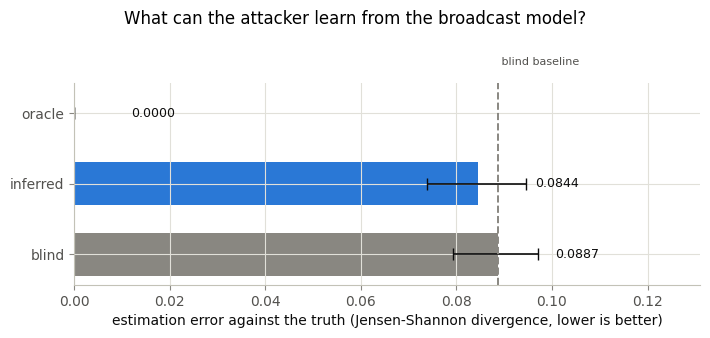

[analysis] saved plot -> docs\figures\dist_knowledge.png


In [9]:
# Score each knowledge level by how far its estimate lands from the truth,
# using Jensen-Shannon divergence. Lower is better, and `blind` is the number
# that matters: an estimator unable to beat "assume uniform" is extracting
# nothing from the model.
#
# `inferred` probes the broadcast model on the PROBE SET, not on the attacker's
# own data. Averaging outputs over the attacker's own inputs mixes in whatever
# that attacker happens to hold, which on a skewed client dominates and yields
# a picture of the attacker rather than of the target.
#
# Run per seed. This is the notebook's central LIMITATION claim, and a negative
# result carried by one seed is not worth much: each seed plants different
# profiles, so the leak could be an accident of one draw.
know_rows = []
for s in CONFIG["SEEDS"]:
    b_k = bundle(s)
    _, tgt_k, _ = sides(b_k)
    truth_k = group_profile(b_k, tgt_k)

    # A few honest rounds so there is a trained model to read the leak from.
    set_global_seeds(s, backend="torch")
    probe_k = SattlerCosineClusterer(eps1=-1.0, scope="head")
    srv_k = TorchFederatedServer(b_k.input_shape, b_k.num_classes, probe_k,
                                 arch=CONFIG["ARCH"],
                                 n_clusters=CONFIG["N_GROUPS"], seed=s)
    for r in range(4):
        srv_k.run_round(b_k.client_data, round_num=r, epochs=CONFIG["EPOCHS"])
    gvec = srv_k.cluster_models[next(iter(srv_k.cluster_models))]

    for mode in CONFIG["KNOWLEDGE"]:
        est = TargetEstimator(
            mode=mode, num_classes=b_k.num_classes, arch=CONFIG["ARCH"],
            input_shape=b_k.input_shape,
            oracle_hist=truth_k if mode == "oracle" else None,
            probe_X=b_k.X_probe if mode == "inferred" else None)
        guess = np.asarray(est.estimate(gvec, b_k.X_probe), dtype=float)
        know_rows.append({"seed": s, "knowledge": mode,
                          "error_vs_truth": js_divergence(guess, truth_k),
                          "truth_skew": float(np.abs(truth_k - 1.0 / b_k.num_classes).sum())})

knowledge = pd.DataFrame(know_rows)
save_run("dist_knowledge", knowledge, source="cfl-distribution.ipynb",
         note="oracle/inferred/blind estimation error, planted distribution groups",
         dataset=CONFIG["DATASET"], overlap=CONFIG["OVERLAP"])
show(knowledge.groupby("knowledge")["error_vs_truth"].mean().round(4).reset_index(),
     "Estimation error by knowledge level, averaged over seeds")
show(knowledge.pivot(index="knowledge", columns="seed", values="error_vs_truth").round(4),
     "Per seed")

print()
for mode, sub in knowledge.groupby("knowledge"):
    m, lo, hi = boot_ci(sub["error_vs_truth"])
    print(f"  {mode:>9}  error {m:.4f} [{lo:.4f}, {hi:.4f}]")

blind_err = knowledge.loc[knowledge.knowledge == "blind", "error_vs_truth"]
inf_err = knowledge.loc[knowledge.knowledge == "inferred", "error_vs_truth"]
gain = 100 * (blind_err.mean() - inf_err.mean()) / blind_err.mean()
bm, blo, bhi = boot_ci(blind_err)
im, ilo, ihi = boot_ci(inf_err)
overlap = not (ihi < blo or bhi < ilo)

print()
print(f"inferred {im:.4f} against blind {bm:.4f}: an improvement of {gain:.0f}%")
print(f"intervals overlap: {overlap}")
print()
if overlap or gain < 25:
    print("Probing the broadcast model is NOT MEASURABLY BETTER than assuming a")
    print("uniform distribution and never probing at all. The model does leak its")
    print("cluster's label distribution, but only by a couple of percentage points")
    print("per class, while the truth it is trying to recover is strongly skewed.")
    print()
    print("This is the binding constraint on the whole distribution channel. An")
    print("attacker told the target distribution imitates it perfectly and for free.")
    print("An attacker that has to work it out from what the server broadcasts")
    print("cannot, so the attack is limited by KNOWLEDGE rather than by capability.")
else:
    print("The leak is large enough to act on, so inference is a viable route and the")
    print("oracle condition is not carrying the result.")

analysis.plot_estimation_error(knowledge, "docs/figures/dist_knowledge.png")

## Part 5. Does the imitation actually move the server's decision?

Estimating a distribution and imitating it is only useful if it changes where the server
puts you. This is the attack proper, against both channels, with a no-attack control.

In [10]:
# Against the DECLARED channel there is nothing to compute: the attacker writes
# the target's profile into the field the server reads. This measures the cost
# of that lie, which is zero.
declared_attack = []
for s in CONFIG["SEEDS"]:
    b_s = bundle(s)
    H_s = partition_label_hists(b_s)
    home_s, tgt_s, _ = sides(b_s)

    for label, hist in (("honest (control)", H_s[CONFIG["ATTACKER"]]),
                        ("declares the target's profile", group_profile(b_s, tgt_s))):
        reported = H_s.copy()
        reported[CONFIG["ATTACKER"]] = hist
        labels, _ = analysis.cluster_by_label_hist(reported, n_clusters=CONFIG["N_GROUPS"])
        # Did the attacker land with the majority of the real target group?
        tgt_members = [i for i in range(CONFIG["NUM_CLIENTS"]) if b_s.groups[i] == tgt_s]
        counts = {}
        for m in tgt_members:
            counts[labels[m]] = counts.get(labels[m], 0) + 1
        declared_attack.append({
            "seed": s, "condition": label,
            "joined_target": bool(labels[CONFIG["ATTACKER"]] == max(counts, key=counts.get))})

da = pd.DataFrame(declared_attack)
show(da.groupby("condition")["joined_target"].mean().round(3).reset_index(),
     "Declared channel: does editing one field move the attacker?")
show(da.pivot(index="condition", columns="seed", values="joined_target"),
     "Per seed (a mean over few seeds can be a seed effect)")

ctrl_rate = da[da.condition == "honest (control)"]["joined_target"].mean()
atk_rate = da[da.condition != "honest (control)"]["joined_target"].mean()
print()
print(f"baseline: the measured honest control, {ctrl_rate:.3f}. NOT 1/K.")
print("An honest client is not placed at random: a working clusterer puts it in its")
print(f"own group. Attack reads {atk_rate:.3f} against that baseline.")
print("\nNo retraining, no weight modification, no accuracy cost. It overwrites the field")
print("the server reads. This is the channel the project's earlier work attacked.")


Declared channel: does editing one field move the attacker?
                    condition  joined_target
declares the target's profile            1.0
             honest (control)            0.0

Per seed (a mean over few seeds can be a seed effect)
seed                               0      1      2      3      4
condition                                                       
declares the target's profile   True   True   True   True   True
honest (control)               False  False  False  False  False

baseline: the measured honest control, 0.000. NOT 1/K.
An honest client is not placed at random: a working clusterer puts it in its
own group. Attack reads 1.000 against that baseline.

No retraining, no weight modification, no accuracy cost. It overwrites the field
the server reads. This is the channel the project's earlier work attacked.


In [11]:
# Against the INFERRED channel the declared field is ignored, so the attacker
# must change what it submits. `data` retrains on a resampled set; the control
# is the same attacker doing nothing (beta=0), which is what makes any effect
# attributable to the imitation rather than to chance.
inferred_rows = []
for s in CONFIG["SEEDS"]:
    b_s = bundle(s)
    home_s, tgt_s, tgt_members = sides(b_s)
    profile_s = group_profile(b_s, tgt_s)

    # Thresholds tuned on an ATTACKER-FREE warmup, so the criterion has never
    # seen the attack it is judging.
    set_global_seeds(s, backend="torch")
    probe_s = SattlerCosineClusterer(eps1=-1.0, scope="head")
    warm = TorchFederatedServer(b_s.input_shape, b_s.num_classes, probe_s,
                                arch=CONFIG["ARCH"], n_clusters=CONFIG["N_GROUPS"], seed=s)
    for r in range(4):
        _, warm_updates, _ = warm.run_round(b_s.client_data, round_num=r,
                                            epochs=CONFIG["EPOCHS"])
    Dw = stack([u.metadata["delta_vec"] for u in warm_updates])[:, probe_s.head_index]
    e1, e2 = SattlerCosineClusterer(scope="head").tune_thresholds(Dw, margin=1.5)

    for label, beta in (("control (beta=0)", 0.0), ("resample to target", 1.0)):
        atk = ClusterSteering(malicious_clients=[CONFIG["ATTACKER"]],
                              target_members=tgt_members, mechanism="data", beta=beta,
                              num_classes=b_s.num_classes, arch=CONFIG["ARCH"],
                              input_shape=b_s.input_shape, seed=s)
        atk.target_hist = profile_s
        clus = SattlerCosineClusterer(eps1=e1, eps2=e2, scope="head",
                                      recursive=False, max_clusters=CONFIG["N_GROUPS"])
        set_global_seeds(s, backend="torch")
        srv = TorchFederatedServer(b_s.input_shape, b_s.num_classes, clus.reset(),
                                   arch=CONFIG["ARCH"], attack=atk,
                                   n_clusters=CONFIG["N_GROUPS"], seed=s)
        hist = srv.fit(b_s.client_data, b_s.X_test, b_s.y_test,
                       rounds=CONFIG["ROUNDS"], epochs=CONFIG["EPOCHS"],
                       client_groups=b_s.groups)
        got = infiltration_of(hist, CONFIG["ATTACKER"], tgt_members)
        accs = [np.mean(list(e["metrics"].values())) for e in hist]
        inferred_rows.append({
            "seed": s, "condition": label,
            "infiltration": float(np.mean(got)) if got else np.nan,
            "post_split_rounds": len(got),
            "final_accuracy": float(accs[-1]) if accs else np.nan})

inferred = pd.DataFrame(inferred_rows)
save_run("dist_attack", inferred, source="cfl-distribution.ipynb",
         note="resample-to-target against the inferred channel, with control",
         dataset=CONFIG["DATASET"], overlap=CONFIG["OVERLAP"])
show(inferred.groupby("condition").agg(
    infiltration=("infiltration", "mean"),
    final_accuracy=("final_accuracy", "mean")).round(3).reset_index(),
    "Inferred channel: does resampling move the server's decision?")
per_seed_breakdown(inferred, "infiltration", "condition")

print()
for cond, sub in inferred.groupby("condition"):
    m, lo, hi = boot_ci(sub["infiltration"].dropna())
    ma, la, ha = boot_ci(sub["final_accuracy"].dropna())
    print(f"  {cond:>19}  infiltration {m:.3f} [{lo:.3f}, {hi:.3f}]"
          f"   accuracy {ma:.3f} [{la:.3f}, {ha:.3f}]")

ctrl = inferred[inferred.condition == "control (beta=0)"]
atk_ = inferred[inferred.condition == "resample to target"]
cost = ctrl["final_accuracy"].mean() - atk_["final_accuracy"].mean()
print()
inf_v = analysis.compare_to_baseline(
    "infiltration", atk_["infiltration"].mean(),
    baseline=ctrl["infiltration"].mean())
acc_v = analysis.compare_to_baseline(
    "accuracy", atk_["final_accuracy"].mean(),
    baseline=ctrl["final_accuracy"].mean(),
    interval=boot_ci(atk_["final_accuracy"])[1:],
    baseline_interval=boot_ci(ctrl["final_accuracy"])[1:])
show(pd.DataFrame([inf_v, acc_v]).round(4), "Each statistic against its baseline")
print()
print(f"accuracy cost of imitating the target: {cost:+.4f}")
if abs(cost) < 0.02:
    print("Imitation is close to free. Resampling changes WHICH distribution the model")
    print("learns, not how well it learns one, so the attacker pays no visible price for")
    print("the disguise. A defence looking for a degraded attacker will not find it.")

[sattler] tuned on 12 attacker-free deltas (scope=head): eps1=3.4191 (||sum d||=2.2794 x 1.5), eps2=0.2221 (max ||d||=0.4442 x 0.5)


[sattler] tuned on 12 attacker-free deltas (scope=head): eps1=3.0787 (||sum d||=2.0525 x 1.5), eps2=0.2229 (max ||d||=0.4458 x 0.5)


[sattler] tuned on 12 attacker-free deltas (scope=head): eps1=3.3463 (||sum d||=2.2309 x 1.5), eps2=0.2213 (max ||d||=0.4427 x 0.5)


[sattler] tuned on 12 attacker-free deltas (scope=head): eps1=3.3183 (||sum d||=2.2122 x 1.5), eps2=0.2391 (max ||d||=0.4782 x 0.5)


[sattler] tuned on 12 attacker-free deltas (scope=head): eps1=3.2157 (||sum d||=2.1438 x 1.5), eps2=0.2197 (max ||d||=0.4394 x 0.5)


[run] dist_attack: 10 rows -> results\runs\20260825-022200_dist_attack
[run] latest copy -> results\dist_attack.csv

Inferred channel: does resampling move the server's decision?
         condition  infiltration  final_accuracy
  control (beta=0)           0.0           0.833
resample to target           1.0           0.843

     control (beta=0)  infiltration 0.000 [0.000, 0.000]   accuracy 0.833 [0.806, 0.855]
   resample to target  infiltration 1.000 [1.000, 1.000]   accuracy 0.843 [0.817, 0.868]


Each statistic against its baseline
   statistic  measured  baseline                             baseline_is    gap                           verdict
infiltration    1.0000    0.0000             the measured honest control 1.0000                    above baseline
    accuracy    0.8429    0.8328 the no-attack control on the same setup 0.0101 not distinguishable from baseline

accuracy cost of imitating the target: -0.0101
Imitation is close to free. Resampling changes WHICH distribution t

## Part 6. Prior-editing, run as an attack rather than shown on paper

Part 3 derived the bias shift arithmetically. This runs it, because "unbounded" is a claim
about behaviour and has to be measured.

The test is the class the attacker holds **none** of. Resampling left it at zero, because
you cannot draw what you do not have. If prior-editing can make the model claim that class,
the two routes differ in kind rather than only in degree.

In [12]:
# Run the prior-edit mechanism, then read the model's ACTUAL output distribution
# off the probe set. The comparison that matters is the class with zero holdings.
prior_rows = []
for s in CONFIG["SEEDS"]:
    b_pr = bundle(s)
    H_pr = partition_label_hists(b_pr)
    home_pr, tgt_pr, tgt_mem_pr = sides(b_pr)
    profile_pr = group_profile(b_pr, tgt_pr)
    own_pr = H_pr[CONFIG["ATTACKER"]]

    atk = ClusterSteering(malicious_clients=[CONFIG["ATTACKER"]],
                          target_members=tgt_mem_pr, mechanism="prior", beta=1.0,
                          num_classes=b_pr.num_classes, arch=CONFIG["ARCH"],
                          input_shape=b_pr.input_shape, seed=s)
    atk.target_hist = profile_pr
    atk.own_data = {CONFIG["ATTACKER"]: b_pr.client_data[CONFIG["ATTACKER"]]}

    set_global_seeds(s, backend="torch")
    srv_pr = TorchFederatedServer(b_pr.input_shape, b_pr.num_classes,
                                  SattlerCosineClusterer(eps1=-1.0, scope="head"),
                                  arch=CONFIG["ARCH"], attack=atk,
                                  n_clusters=CONFIG["N_GROUPS"], seed=s)
    _, upd_pr, _ = srv_pr.run_round(b_pr.client_data, round_num=0,
                                    epochs=CONFIG["EPOCHS"])
    claimed = mean_output_prior_torch(CONFIG["ARCH"], upd_pr[CONFIG["ATTACKER"]].vec,
                                      b_pr.input_shape, b_pr.num_classes, b_pr.X_probe)

    for c in range(b_pr.num_classes):
        if own_pr[c] == 0:
            prior_rows.append({"seed": s, "class": c,
                               "attacker_holds": float(own_pr[c]),
                               "resampling_achieves": 0.0,
                               "target_wants": float(profile_pr[c]),
                               "prior_edit_claims": float(claimed[c])})

prior_edit = pd.DataFrame(prior_rows)
if len(prior_edit):
    show(prior_edit.round(4), "Classes the attacker holds NONE of")
    print()
    print("baseline: resampling leaves these at exactly 0.000, because a class you do")
    print("not hold cannot be drawn. That column is the norm this is measured against.")
    print()
    print(f"prior-editing claims {prior_edit['prior_edit_claims'].mean():.3f} on average,")
    print(f"against a target of {prior_edit['target_wants'].mean():.3f} and holdings of 0.")
    print()
    print("So the two routes differ in KIND. Resampling is bounded by what the attacker")
    print("owns; prior-editing is bounded by nothing, and yields a model that reports a")
    print("distribution it never learned.")
else:
    print("No zero-holding classes at this overlap, so the bound cannot be shown.")
    print("Lower CONFIG['OVERLAP'] to make the groups more disjoint.")


Classes the attacker holds NONE of
 seed  class  attacker_holds  resampling_achieves  target_wants  prior_edit_claims
    0      2             0.0                  0.0        0.1456             0.1486
    1      6             0.0                  0.0        0.1707             0.1871
    1      8             0.0                  0.0        0.1246             0.1312
    2      9             0.0                  0.0        0.1553             0.1847
    3      1             0.0                  0.0        0.1276             0.1266
    4      2             0.0                  0.0        0.1501             0.1513

baseline: resampling leaves these at exactly 0.000, because a class you do
not hold cannot be drawn. That column is the norm this is measured against.

prior-editing claims 0.155 on average,
against a target of 0.146 and holdings of 0.

So the two routes differ in KIND. Resampling is bounded by what the attacker
owns; prior-editing is bounded by nothing, and yields a model that r

## Part 7. Does robust aggregation change any of this?

Everything so far uses plain Federated Averaging, the weakest aggregator and one no serious
deployment would use alone. The standard robust rules are Krum, Multi-Krum, coordinate-wise
median, trimmed mean and Bulyan, reimplemented in `aggregation.py` from the published
equations and cross-checked against the ByzFL library.

The question splits in two, and the two halves have different answers:

- does the attacker still get **placed** in the target cluster?
- does the **damage** still land once it is inside?

[sattler] tuned on 12 attacker-free deltas (scope=head): eps1=3.4191 (||sum d||=2.2794 x 1.5), eps2=0.2221 (max ||d||=0.4442 x 0.5)


[sattler] tuned on 12 attacker-free deltas (scope=head): eps1=3.0787 (||sum d||=2.0525 x 1.5), eps2=0.2229 (max ||d||=0.4458 x 0.5)


[sattler] tuned on 12 attacker-free deltas (scope=head): eps1=3.3463 (||sum d||=2.2309 x 1.5), eps2=0.2213 (max ||d||=0.4427 x 0.5)


[run] dist_aggregators: 36 rows -> results\runs\20260825-023439_dist_aggregators
[run] latest copy -> results\dist_aggregators.csv

Placement under each aggregation rule (control beside attacked)
condition   control  resample + boost x2
aggregator                              
bulyan          0.0                  1.0
fedavg          0.0                  1.0
krum            0.0                  1.0
median          0.0                  1.0
multikrum       0.0                  1.0
trimmed         0.0                  1.0

Accuracy under each rule
condition   control  resample + boost x2
aggregator                              
bulyan        0.842                0.844
fedavg        0.840                0.428
krum          0.756                0.782
median        0.853                0.870
multikrum     0.834                0.824
trimmed       0.851                0.869

baseline: each rule is read against ITS OWN control, not against FedAvg. The
rules do not all reach the same accuracy wit

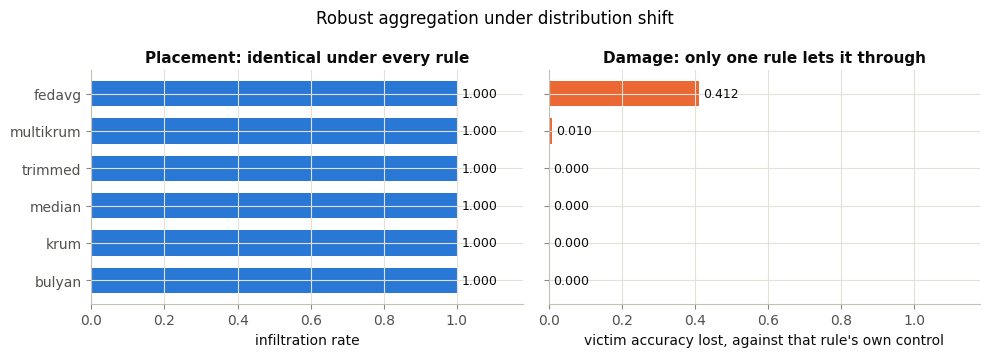

[analysis] saved plot -> docs\figures\dist_aggregators.png

accuracy lost to the payload, against each rule's own control:
      fedavg: +0.4119
   multikrum: +0.0098
      bulyan: -0.0025
      median: -0.0173
     trimmed: -0.0184
        krum: -0.0254

placement: 1.000 attacked against 0.000 control, pooled
across rules, range 1.000 to 1.000

Placement is flat across every rule, so robust aggregation is not governing
it. Clustering decides who you are grouped with; aggregation decides whose
update counts. A robust aggregator only touches the second.


In [13]:
# Placement and damage under each aggregation rule. The attacker resamples to the
# target and then amplifies, so both halves of the attack are present and can be
# scored separately.
#
# Fewer seeds here than elsewhere: six rules times two conditions is the most
# expensive cell in the notebook.
AGG_SEEDS = CONFIG["SEEDS"][:3]
AGGREGATORS = ("fedavg", "krum", "multikrum", "median", "trimmed", "bulyan")

agg_rows = []
for s in AGG_SEEDS:
    b_a = bundle(s)
    home_a, tgt_a, tgt_mem_a = sides(b_a)
    profile_a = group_profile(b_a, tgt_a)

    set_global_seeds(s, backend="torch")
    probe_a = SattlerCosineClusterer(eps1=-1.0, scope="head")
    warm_a = TorchFederatedServer(b_a.input_shape, b_a.num_classes, probe_a,
                                  arch=CONFIG["ARCH"],
                                  n_clusters=CONFIG["N_GROUPS"], seed=s)
    for r in range(4):
        _, wu, _ = warm_a.run_round(b_a.client_data, round_num=r,
                                    epochs=CONFIG["EPOCHS"])
    Dwa = stack([u.metadata["delta_vec"] for u in wu])[:, probe_a.head_index]
    ea1, ea2 = SattlerCosineClusterer(scope="head").tune_thresholds(Dwa, margin=1.5)

    for agg in AGGREGATORS:
        for label, beta, payload in (("control", 0.0, "none"),
                                     ("resample + boost x2", 1.0, "boost")):
            atk = ClusterSteering(
                malicious_clients=[CONFIG["ATTACKER"]], target_members=tgt_mem_a,
                mechanism="data", beta=beta, num_classes=b_a.num_classes,
                arch=CONFIG["ARCH"], input_shape=b_a.input_shape, seed=s,
                payload=payload, payload_scale=2.0)
            atk.target_hist = profile_a
            clus = SattlerCosineClusterer(eps1=ea1, eps2=ea2, scope="head",
                                          recursive=False,
                                          max_clusters=CONFIG["N_GROUPS"])
            set_global_seeds(s, backend="torch")
            srv_a = TorchFederatedServer(b_a.input_shape, b_a.num_classes,
                                         clus.reset(), arch=CONFIG["ARCH"],
                                         attack=atk, aggregator=agg,
                                         n_clusters=CONFIG["N_GROUPS"], seed=s)
            h_a = srv_a.fit(b_a.client_data, b_a.X_test, b_a.y_test,
                            rounds=CONFIG["ROUNDS"], epochs=CONFIG["EPOCHS"],
                            client_groups=b_a.groups)
            got = infiltration_of(h_a, CONFIG["ATTACKER"], tgt_mem_a)
            accs = [np.mean(list(e["metrics"].values())) for e in h_a]
            agg_rows.append({"seed": s, "aggregator": agg, "condition": label,
                             "infiltration": float(np.mean(got)) if got else np.nan,
                             "final_accuracy": float(accs[-1]) if accs else np.nan})

aggregation = pd.DataFrame(agg_rows)
save_run("dist_aggregators", aggregation, source="cfl-distribution.ipynb",
         note="six aggregation rules, control beside attacked, per-rule baselines",
         dataset=CONFIG["DATASET"], overlap=CONFIG["OVERLAP"])
show(aggregation.pivot_table(index="aggregator", columns="condition",
                             values="infiltration").round(3),
     "Placement under each aggregation rule (control beside attacked)")
show(aggregation.pivot_table(index="aggregator", columns="condition",
                             values="final_accuracy").round(3),
     "Accuracy under each rule")

print()
print("baseline: each rule is read against ITS OWN control, not against FedAvg. The")
print("rules do not all reach the same accuracy with no attacker present, so a shared")
print("reference would credit or penalise them for a difference the attack did not cause.")

analysis.plot_aggregator_outcome(aggregation, "docs/figures/dist_aggregators.png",
                                 attacked_label="resample + boost x2",
                                 acc_col="final_accuracy",
                                 title="Robust aggregation under distribution shift")

ctrl_a = aggregation[aggregation.condition == "control"].set_index(["seed", "aggregator"])
atk_a = aggregation[aggregation.condition != "control"].set_index(["seed", "aggregator"])
lost = (ctrl_a["final_accuracy"] - atk_a["final_accuracy"]).groupby("aggregator").mean()
print()
print("accuracy lost to the payload, against each rule's own control:")
for agg, v in lost.sort_values(ascending=False).items():
    print(f"  {agg:>10}: {v:+.4f}")

inf_atk = atk_a["infiltration"].mean()
inf_ctrl = ctrl_a["infiltration"].mean()
spread = atk_a.groupby("aggregator")["infiltration"].mean()
print()
print(f"placement: {inf_atk:.3f} attacked against {inf_ctrl:.3f} control, pooled")
print(f"across rules, range {spread.min():.3f} to {spread.max():.3f}")
print()
if spread.max() - spread.min() < 0.2:
    print("Placement is flat across every rule, so robust aggregation is not governing")
    print("it. Clustering decides who you are grouped with; aggregation decides whose")
    print("update counts. A robust aggregator only touches the second.")
else:
    print("Placement varies by rule, so the aggregator IS affecting who gets grouped")
    print("where, and the two decisions are not as separable as the concept-shift")
    print("notebook found them to be.")

## What this establishes

Every number below is from the cells above, five seeds, each against its own baseline.

**The setting is not a free choice.** Statistical heterogeneity only supports a clustering
study when the heterogeneity is *grouped*. Dirichlet partitioning, the standard
non-Independent-and-Identically-Distributed generator, gives every client its own skew and
no group structure: across concentration 0.05 to 1.0, the best two-way split that exists
*anywhere* in it scores 1.43 to 1.65, against a median random split of 0.99. Planted
profiles score 4.51 at the operating point and 17.31 when disjoint. A study run on Dirichlet
is measuring infiltration into an arbitrary set of clients.

**Both channels give the server something real, and both are spoofable.**

| channel | server recovers groups at | attacked | control |
|---|---|---|---|
| declared label histogram | ARI **1.000** | **1.000** | 0.000 |
| inferred from updates | AUC **1.000** on the head | **1.000** | 0.000 |

**Imitation is free.** Resampling to the target reaches 1.000 infiltration while accuracy
moves 0.833 to 0.843, which is *not distinguishable* from the no-attack control. Resampling
changes which distribution the model learns, not how well it learns one, so the attacker
pays no visible price for the disguise and a defence looking for a degraded attacker will
not find one.

**The two imitation routes differ in kind, not degree.** On classes the attacker holds
**none** of, resampling achieves exactly 0.000, because a class you do not hold cannot be
drawn. Prior-editing claims **0.155** on those same classes against a target of 0.146.
Resampling yields a model that has *learned* the distribution; prior-editing yields one that
merely *reports* it.

**The binding constraint is knowledge, not capability.** Estimating the target's
distribution by probing the broadcast model gives error 0.0844 against 0.0887 for assuming
uniform and never probing at all. The intervals overlap, so the two are **not
distinguishable**. An attacker *told* the distribution imitates it perfectly and for free;
an attacker that must *work it out* from what the server broadcasts cannot.

**Robust aggregation does not prevent the intrusion.** Placement is **1.000 under all six
rules** against a 0.000 control, range 1.000 to 1.000. Damage lands only under plain
Federated Averaging, which loses 0.41 accuracy against its own control while every robust
rule loses nothing. Clustering decides who you are grouped with, aggregation decides whose
update counts, and a robust aggregator governs only the second.

> This replicates the concept-shift result in `cfl-spoofing.ipynb` exactly. The same
> structural finding under two different kinds of heterogeneity is a replication rather than
> a single experiment, and it is the evidence for correcting the claim in the project report
> that spoofing defeats Byzantine-robust defences. It does not: it defeats robust
> *clustering* completely and robust *aggregation* not at all.

## What this does not establish

1. **One dataset, one architecture.** MNIST with a Multi-Layer Perceptron.
2. **One attacker in twelve**, which is 8.3%. The literature runs 1 to 30%.
3. **The aggregator sweep uses three seeds**, not five, being the most expensive cell here.
4. **No defence is measured**, by choice. There is therefore no false positive rate.
5. **Prior-editing is measured for what it CLAIMS**, through the model's output distribution,
   not for whether that claim survives contact with a server that checks behaviour.